# 0-Set Up

In [1]:
import io, requests, pandas as pd

ENDPOINT = "https://publications.europa.eu/webapi/rdf/sparql"
AUTH = "http://publications.europa.eu/resource/authority/"
PREFIXES = """
PREFIX cdm: <http://publications.europa.eu/ontology/cdm#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
"""
ENG = f"<{AUTH}language/ENG>"

Q_EUROVOC = f"""{PREFIXES}
SELECT DISTINCT ?work ?agent ?type ?date ?title WHERE {{
  ?work cdm:work_is_about_concept_eurovoc <http://eurovoc.europa.eu/3030> ;
        cdm:work_created_by_agent ?agent ;
        cdm:work_date_document ?date .
  OPTIONAL {{ ?work cdm:work_has_resource-type ?type }}
  OPTIONAL {{ ?e cdm:expression_belongs_to_work ?work ;
                cdm:expression_uses_language {ENG} ;
                cdm:expression_title ?title }}
  FILTER(?date >= "2020-01-01"^^xsd:date)
}}"""

Q_TITLE = f"""{PREFIXES}
SELECT DISTINCT ?work ?agent ?type ?date ?title WHERE {{
  ?e cdm:expression_belongs_to_work ?work ;
     cdm:expression_uses_language {ENG} ;
     cdm:expression_title ?title .
  ?work cdm:work_created_by_agent ?agent ;
        cdm:work_date_document ?date .
  OPTIONAL {{ ?work cdm:work_has_resource-type ?type }}
  FILTER(?date >= "2020-01-01"^^xsd:date)
  FILTER(CONTAINS(LCASE(STR(?title)), "artificial intelligence"))
}}"""

def run(q):
    r = requests.get(ENDPOINT,params={"query": q},
        headers={"Accept": "text/csv"},timeout=180
    )
    r.raise_for_status()

    df = pd.read_csv(io.StringIO(r.text))

    for c in df.columns:
        df[c] = (df[c].astype("string")
            .str.replace(AUTH, "", regex=False)
        )

    return df

COMMISSION = {"COM","SG","SJ","CNECT","RTD","COMP","JUST","EMPL","GROW","HOME","TRADE",
              "SANTE","ENER","MOVE","EAC","ECFIN","FISMA","AGRI","ENV","CLIMA","DEFIS",
              "DIGIT","JRC","EISMEA","EASME","HADEA","REA","ERCEA","CINEA","EACEA","ESTAT",
              "OLAF","TAXUD","MARE","REGIO","INTPA","NEAR","ECHO","BUDG","HR","COMM","OIB"}

def institution(agent):
    code = str(agent).split("/")[-1]
    if code == "CONSIL": return "Council"
    if code == "EP" or code.startswith("EP_"): return "Parliament"
    if code in COMMISSION: return "Commission"
    return None

# scope rules: CELLAR resource type -> in/out (same as data/doc_types.csv)
IN_SCOPE = {"COMMUNIC","JOINT_COMMUNIC","COMMUNIC_POSIT","PAPER_WHITE","SWD",
            "IMPACT_ASSESS","IMPACT_ASSESS_SUM","IMPACT_ASSESS_INCEP","EVL",
            "FACT_SUM_REPORT_CONSULT","PROP_REG","PROP_DIR","PROP_DEC","RECO","RECO_DEC",
            "REPORT","REPORT_EP","REPORT_DRAFT_EP_CMT","OWNINI_RES","RES_LEGIS","RES",
            "ADOPT_TEXT","OPIN_EP_CMT","OPIN_LETTER_EP_CMT","AMEND_LIST_EP","NOTE",
            "ITEM_IA_NOTE","NOTE_INFO","CONCL","POSIT","DECLAR","STAT_REASON","STAT",
            "AGREE_PROV"}

u = pd.concat([run(Q_EUROVOC), run(Q_TITLE)])
u["institution"] = u["agent"].map(institution)
u = u.dropna(subset=["institution"])
u["type"] = u["type"].str.replace("resource-type/", "", regex=False)

# exclude works attributed to more than one institution (co-signed acts, joint declarations)
n_inst = u.drop_duplicates(["work", "institution"]).groupby("work")["institution"].nunique()

works = (u.groupby("work")
           .agg(institution=("institution", "first"), type=("type", "first"),
                date=("date", "first"), title=("title", "first"))
           .reset_index())
works["joint"] = works["work"].map(n_inst).gt(1)
works["in_scope"] = works["type"].isin(IN_SCOPE) & ~works["joint"]

core = works[works["in_scope"]]
print("Found:", len(works), "| In scope:", len(core))
print(core.groupby("institution").size())
print(core.assign(year=pd.to_datetime(core["date"]).dt.year)
          .pivot_table(index="year", columns="institution", values="work",
                       aggfunc="count", fill_value=0))


Found: 647 | In scope: 191
institution
Commission    80
Council       42
Parliament    69
dtype: int64
institution  Commission  Council  Parliament
year                                        
2020                  6        2           5
2021                  7        2           7
2022                 10        1           8
2023                  3        2           3
2024                  4       11           8
2025                 27        2          11
2026                 23       22          27


In [2]:
# The retrieval date is recorded in the filename to preserve a reproducible snapshot of the corpus at each stage of the project.
import os
os.makedirs("data", exist_ok=True)
import datetime
retrieval_date = datetime.date.today().isoformat()
works.to_csv(f"data/raw_works_{retrieval_date}.csv", index=False)
print(f"Retrieved {len(works)} works on {retrieval_date}")
print("Observation period: 2020-01-01 to present")
print("Retrieval strategy: EuroVoc AI concept OR English title contains 'artificial intelligence'")

Retrieved 647 works on 2026-09-05
Observation period: 2020-01-01 to present
Retrieval strategy: EuroVoc AI concept OR English title contains 'artificial intelligence'


# 1-Feasibility Assessment

## 1.1 Access Feasibility

The CELLAR SPARQL endpoint is publicly accessible and does not require an API key or authentication. Both queries (EuroVoc tag match and English title match) executed successfully within the 180s timeout and returned a combined N=647 raw records across all three institutions

## 1.2 Scope Feasibility

In [3]:
# Convert the date string to datetime, extract the year, and store it as a new column for grouping by year in pivot table
works["year"] = pd.to_datetime(works["date"]).dt.year
core = works.loc[works["in_scope"]].copy()

In [4]:
print("\nRaw corpus size:", works.shape)
print("\nDocuments by institution (raw):")
print(works["institution"].value_counts())

print("\nDocuments by year and institution (raw):")
print(works.pivot_table(index="year", columns="institution",
                         values="work", aggfunc="count", fill_value=0))

print("\nDocument types (raw):")
print(works.groupby(["institution", "type"]).size().sort_values(ascending=False))

print("\nJoint/co-signed works excluded:", works["joint"].sum())


Raw corpus size: (647, 8)

Documents by institution (raw):
institution
Commission    412
Parliament    124
Council       111
Name: count, dtype: int64

Documents by year and institution (raw):
institution  Commission  Council  Parliament
year                                        
2020                 14        2           8
2021                 30       15           9
2022                 66       11          30
2023                 61        5           8
2024                 71       24          18
2025                126       14          21
2026                 44       40          30

Document types (raw):
institution  type                   
Commission   PUB_GEN                    286
Parliament   PUB_GEN                     48
Council      NOTE_COVER                  31
             NOTE                        23
Parliament   OWNINI_RES                  21
Commission   COMMUNIC                    18
             SWD                         15
             ANNOUNC             

From the result above:
The CELLAR-based retrieval strategy is technically feasible and yields a sufficiently large cross-institutional corpus, but the initial retrieval contains substantial heterogeneity in document type and institutional coverage. This makes eligibility filtering and controls for document type and time necessary before substantive framing analysis.

In [5]:
TYPE_REASONS = {
    "PUB_GEN": "research output (JRC/DG reports), not institutional position",
    "NOTE_COVER": "Council forwarded but did not author",
    "CORRIGENDUM": "administrative correction, not substantive",
    "PLENARY_MINUTES_EP": "procedural minutes",
    "FACTSHEET": "not institutional position",
    "ACT_LEGIS": "adopted legal act, co-signed across institutions",
    "REG": "adopted regulation, co-signed",
    "DEC": "adopted decision, co-signed",
    "REG_IMPL": "adopted implementing regulation, legal act",
    "DEC_IMPL": "adopted implementing decision, legal act",
    "PROP_ACT": "Council mirror copy of Commission proposal, not Council-authored",
    "STU": "commissioned study, research output",
    "NOTICE": "competition-clearance administrative notice, not AI policy statement",
    "ITEM_I_NOTE": "procedural item note, not substantive position",
    "FACT_SUM_REPORT_CONSULT": "included per team decision: summarizes consultation input relevant to institutional position",
    "NOTE_INFO": "included per team decision: informational note treated as substantive enough for corpus",
    "AGREE_PROV": "included per team decision: provisional agreement text retained; flagged for inherited-share quantification given co-negotiated content",
}

In [6]:
doc_types_rows = []
for t in sorted(works["type"].unique()):
    decision = "include" if t in IN_SCOPE else "exclude"
    reason = TYPE_REASONS.get(t, "not in scope list; see manual spot-check" if decision == "exclude" else "")
    doc_types_rows.append({"type": t, "decision": decision, "reason": reason})

doc_types_df = pd.DataFrame(doc_types_rows)
doc_types_df.to_csv("data/doc_types.csv", index=False)
print(f"\nSaved scope decisions for {len(doc_types_df)} types to data/doc_types.csv")



Saved scope decisions for 51 types to data/doc_types.csv


## Ambiguous Test

Here, a manual spot-check on these borderline document types to see what they actually are, then decide if the inclusion rule makes sense. We choose "EVL", "STAT", "FACT_SUM_REPORT_CONSULT", "NOTE_INFO", "AGREE_PROV", because we cannot make certain decision simply relying on their names.

In [7]:
AMBIGUOUS_TYPES = ["EVL", "STAT", "FACT_SUM_REPORT_CONSULT", "NOTE_INFO", "AGREE_PROV"]

for t in AMBIGUOUS_TYPES:
    subset = works[works["type"] == t][["institution", "date", "title"]]
    print(f"\n{'='*80}\n{t}  (n={len(subset)})")
    print(subset.to_string(index=False))


EVL  (n=2)
institution       date                                                                                                                                                                                                                                                                                                                                           title
 Commission 2025-12-18 COMMISSION STAFF WORKING DOCUMENT EVALUATION Interim Evaluation of the Digital Europe Programme Accompanying the document REPORT FROM THE COMMISSION TO THE EUROPEAN PARLIAMENT, THE COUNCIL, THE EUROPEAN ECONOMIC AND SOCIAL COMMITTEE AND THE COMMITTEE OF THE REGIONS The Digital Europe Programme: Main findings of the interim evaluation
 Commission 2026-01-21                                                                                                                                                           COMMISSION STAFF WORKING DOCUMENT EVALUATION Accompanying the document REPORT FROM THE COMMIS

EVL need to be excluded because the sampled documents were broad programme/institution evaluations rather than AI-specific policy-position documents. STAT and FACT_SUM_REPORT_CONSULT were retained because they contain substantive Commission positions related to AI. NOTE_INFO was retained as Council legislative-process material.AGREE_PROV was retained but flagged for a robustness check because provisional agreements reflect interinstitutional negotiation rather than an independent institutional position

### Manual Audit

In [8]:
for inst_name, group in core.groupby("institution"):
    print("\nInstitution:", institution)
    sample = group[["type", "date", "title"]].sample(
        min(5, len(group)), random_state=42
    )

    for _, row in sample.iterrows():
        print(f"\nTYPE: {row['type']}")
        print(f"DATE: {row['date']}")
        print(f"TITLE: {row['title']}")


Institution: <function institution at 0x71febc7ce200>

TYPE: SWD
DATE: 2026-04-28
TITLE: COMMISSION STAFF WORKING DOCUMENT Accompanying the document Report from the Commission to the European Parliament, the Council and the European Economic and Social Committee on the Review of Regulation (EU) 2022/1925 of the European Parliament and of the Council on contestable and fair markets in the digital sector and amending Directives (EU) 2019/1937 and (EU) 2020/1828 (Digital Markets Act), in accordance with Article 53 thereof

TYPE: IMPACT_ASSESS_SUM
DATE: 2021-04-21
TITLE: COMMISSION STAFF WORKING DOCUMENT EXECUTIVE SUMMARY OF THE IMPACT ASSESSMENT REPORT Accompanying the Proposal for a Regulation of the European Parliament and of the Council LAYING DOWN HARMONISED RULES ON ARTIFICIAL INTELLIGENCE (ARTIFICIAL INTELLIGENCE ACT) AND AMENDING CERTAIN UNION LEGISLATIVE ACTS

TYPE: IMPACT_ASSESS
DATE: 2022-09-28
TITLE: COMMISSION STAFF WORKING DOCUMENT IMPACT ASSESSMENT REPORT Accompanying the d

## 1.4 Limitation-- metadata completeness


In [9]:
metadata_cols = ["work", "institution", "date", "type", "title"]

print("\nMissing values overall:")
print(works[metadata_cols].isna().sum())

print("\nMissing values by institution:")
print(works.groupby("institution")[metadata_cols].apply(
    lambda x: x.isna().sum(), include_groups=False))


Missing values overall:
work            0
institution     0
date            0
type            0
title          13
dtype: int64

Missing values by institution:
             work  institution  date  type  title
institution                                      
Commission      0            0     0     0      5
Council         0            0     0     0      8
Parliament      0            0     0     0      0


The results show work, institution, date,type short have no missing values. It signals that CELLAR provides sufficiently complete core metadata for constructing the institutional comparison corpus.

However, title metadata are slightly less complete, with 13 records (2.05%) missing titles.

Missing-title records are disproportionately concentrated in the Council subset, suggesting that metadata completeness may vary somewhat by institution.

# 2. Initial Exploration

## 2.1 Basic Counts

In [15]:
year_inst = core.pivot_table(index="year", columns="institution",
                              values="work", aggfunc="count", fill_value=0)
print("\nIn-scope documents by year and institution:")
print(year_inst)

type_inst = core.groupby(["institution", "type"]).size().sort_values(ascending=False)
print("\nIn-scope documents by type (top 15):")
print(type_inst.head(15))

summary_stats = core.groupby("institution").agg(
    n_docs=("work", "count"), n_types=("type", "nunique"),
    earliest=("date", "min"), latest=("date", "max"))
print("\nPer-institution summary (in-scope):")
print(summary_stats)

# Representative Examples
print("\nRepresentative examples:")

for institution, group in core.groupby("institution"):
    examples = group.sort_values("date").iloc[[0, -1]]

    print("\n")
    print("Institution:", institution)


    for _, row in examples.iterrows():
        print(f"\nTYPE: {row['type']}")
        print(f"DATE: {row['date']}")
        print(f"TITLE: {row['title']}")



In-scope documents by year and institution:
institution  Commission  Council  Parliament
year                                        
2020                  6        2           5
2021                  7        2           7
2022                 10        1           8
2023                  3        2           3
2024                  4       11           8
2025                 27        2          11
2026                 23       22          27

In-scope documents by type (top 15):
institution  type         
Council      NOTE             22
Parliament   OWNINI_RES       21
Commission   COMMUNIC         18
             SWD              15
             REPORT           13
Parliament   OPIN_EP_CMT      10
Council      ITEM_IA_NOTE      9
Parliament   RES_LEGIS         8
             AMEND_LIST_EP     8
             ADOPT_TEXT        7
Commission   PROP_REG          6
Parliament   REPORT            6
Commission   PROP_DEC          4
Council      CONCL             4
Commission   RECO      

## 2.2 Figure

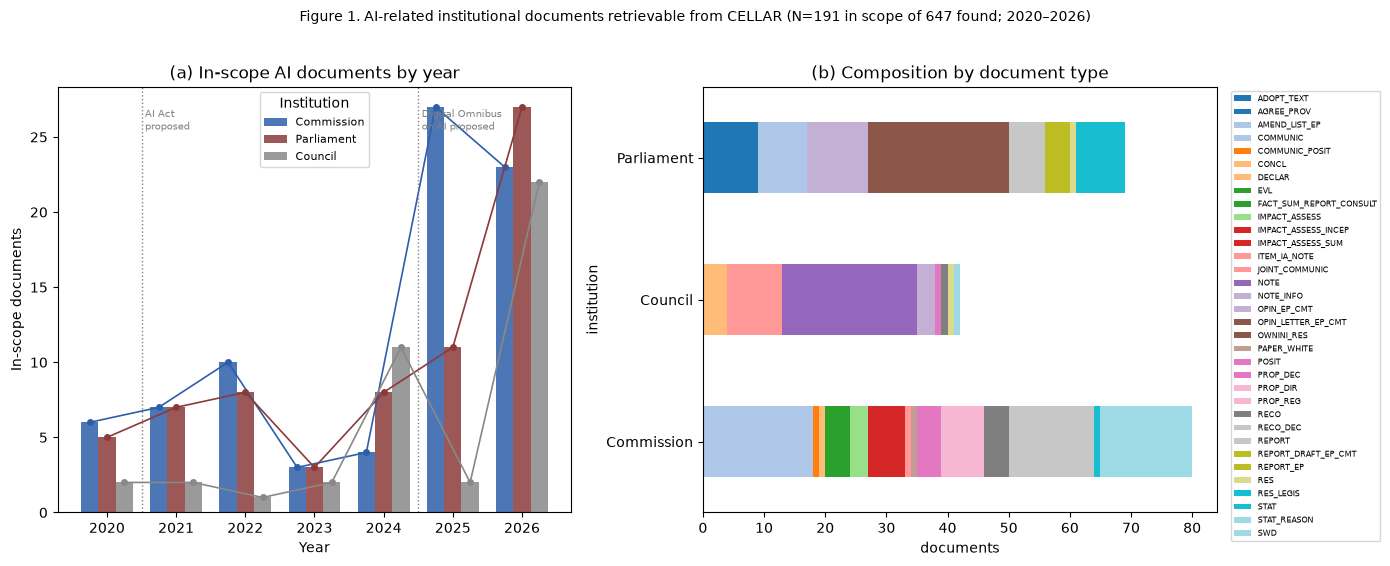

In [16]:
# Add a figure folder
!mkdir -p figures

# Code
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

years = year_inst.index.tolist()
x = np.arange(len(years))
width = 0.25
colors = {"Commission": "#2E5EAA", "Parliament": "#8B3A3A", "Council": "#888888"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
for i, inst in enumerate(["Commission", "Parliament", "Council"]):
    offset = (i - 1) * width
    ax1.bar(x + offset, year_inst[inst], width, label=inst, color=colors[inst], alpha=0.85)
    ax1.plot(x + offset, year_inst[inst], color=colors[inst], marker="o", markersize=4, linewidth=1.2)

for year_mark, label in [(2021, "AI Act\nproposed"), (2025, "Digital Omnibus\non AI proposed")]:
    if year_mark in years:
        xpos = years.index(year_mark) - 0.5
        ax1.axvline(x=xpos, color="grey", linestyle=":", linewidth=1)
        ax1.text(xpos + 0.05, ax1.get_ylim()[1]*0.95, label, fontsize=7.5, color="grey", va="top")

ax1.set_xticks(x); ax1.set_xticklabels(years)
ax1.set_xlabel("Year"); ax1.set_ylabel("In-scope documents")
ax1.set_title("(a) In-scope AI documents by year")
ax1.legend(title="Institution", fontsize=8)


type_inst_wide = core.groupby(["institution", "type"]).size().unstack(fill_value=0)
type_inst_wide.plot(kind="barh", stacked=True, ax=ax2, colormap="tab20")
ax2.set_xlabel("documents"); ax2.set_title("(b) Composition by document type")
ax2.legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle(f"Figure 1. AI-related institutional documents retrievable from CELLAR "
             f"(N={len(core)} in scope of {len(works)} found; 2020–2026)", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig("figures/week2_combined.png", dpi=150, bbox_inches="tight")
plt.show()